In [44]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Credit Risk Assessment

```
Sebagai tugas akhir dari masa kontrakmu sebagai intern Data Scientist di ID/X Partners, kali ini kamu akan dilibatkan dalam projek dari sebuah lending company. Kamu akan berkolaborasi dengan berbagai departemen lain dalam projek ini untuk menyediakan solusi teknologi bagi company tersebut. Kamu diminta untuk membangun model yang dapat memprediksi credit risk menggunakan dataset yang disediakan oleh company yang terdiri dari data pinjaman yang diterima dan yang ditolak. Selain itu kamu juga perlu mempersiapkan media visual untuk mempresentasikan solusi ke klien. Pastikan media visual yang kamu buat jelas, mudah dibaca, dan komunikatif. Pengerjaan end-to-end solution ini dapat dilakukan di Programming Language pilihanmu dengan tetap mengacu kepada framework/methodology Data Science.
```

In [45]:
import pandas as pd
import numpy as np

import src.utils as utils

import warnings
warnings.filterwarnings('ignore')

In [46]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Data Preparation

In [47]:
df = pd.read_csv('input/loan_data_2007_2014.csv', engine='pyarrow')

utils.skim_data(df)

Total duplicate rows: 0
DF shape: (466285, 75)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,,int64,0.000,0.0,0.0,466285,100.00,"[0, 1, 2, 3, 4]"
1,id,int64,0.000,0.0,0.0,466285,100.00,"[1077501, 1077430, 1077175, 1076863, 1075358]"
2,member_id,int64,0.000,0.0,0.0,466285,100.00,"[1296599, 1314167, 1313524, 1277178, 1311748]"
3,loan_amnt,int64,0.000,0.0,0.0,1352,0.29,"[5000, 2500, 2400, 10000, 3000]"
4,funded_amnt,int64,0.000,0.0,0.0,1354,0.29,"[5000, 2500, 2400, 10000, 3000]"
5,funded_amnt_inv,float64,0.000,0.0,0.05,9854,2.11,"[4975.0, 2500.0, 2400.0, 10000.0, 3000.0]"
6,term,object,0.000,-,-,2,0.00,"[ 36 months, 60 months]"
7,int_rate,float64,0.000,0.0,0.0,506,0.11,"[10.65, 15.27, 15.96, 13.49, 12.69]"
8,installment,float64,0.000,0.0,0.0,55622,11.93,"[162.87, 59.83, 84.33, 339.31, 67.79]"
9,grade,object,0.000,-,-,7,0.00,"[B, C, A, E, F]"


Berdasarkan hasil `skim_data`, terdapat 466.285 baris data dan 75 kolom fitur. Kolom targetnya adalah `loan_status`. Dari jumlah baris sebanyak itu, tidak terlihat ada data duplikat. Meskipun demikian, 75 fitur ini masih dapat dikurangi untuk mempermudah eksplorasi dan membuat model jadi lebih efisien dan akurat. Ada beberapa langkah yang bisa saya lakukan untuk mengurangi jumlah fitur ini, yaitu:

- Filter berdasarkan identitas dan informasi administratif: membuang fitur seperti nama dan ID nasabah, karena fitur seperti itu tidak memiliki nilai prediktif.
- Filter berdasarkan kualitas data: membuang (a) fitur yang memiliki *missing values* yang terlalu banyak dan (b) fitur yang hanya memiliki satu nilai unik karena fitur ini tidak memberikan informasi pembeda bagi model.
- Filter berdasarkan fitur yang berpotensi menimbulkan *data leakage*.
- Filter statistik: membuat heatmap korelasi antar fitur (bukan dibandingkan dengan target). Apabila ada dua fitur yang berkorelasi tinggi, bisa pilih salah satu saja.

### Identifying IDs and Adminstrative Informations

Fitur-fitur yang tergolong dalam kategori ini adalah `id`, `member_id`, `url`, `desc`, `policy_code`, `Unnamed: 0`, `emp_title`, `title`, dan `zip_code`.

In [48]:
df = df.drop(columns=['id', 'member_id', 'url', 'desc', 'policy_code', '', 'emp_title', 'title', 'zip_code'])
skim_result = utils.skim_data(df)

skim_result

Total duplicate rows: 0
DF shape: (466285, 66)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1352,0.29,"[5000, 2500, 2400, 10000, 3000]"
1,funded_amnt,int64,0.000,0.0,0.0,1354,0.29,"[5000, 2500, 2400, 10000, 3000]"
2,funded_amnt_inv,float64,0.000,0.0,0.05,9854,2.11,"[4975.0, 2500.0, 2400.0, 10000.0, 3000.0]"
3,term,object,0.000,-,-,2,0.00,"[ 36 months, 60 months]"
4,int_rate,float64,0.000,0.0,0.0,506,0.11,"[10.65, 15.27, 15.96, 13.49, 12.69]"
5,installment,float64,0.000,0.0,0.0,55622,11.93,"[162.87, 59.83, 84.33, 339.31, 67.79]"
6,grade,object,0.000,-,-,7,0.00,"[B, C, A, E, F]"
7,sub_grade,object,0.000,-,-,35,0.01,"[B2, C4, C5, C1, B5]"
8,emp_length,object,4.505,-,-,11,0.00,"[10+ years, < 1 year, 1 year, 3 years, 8 years]"
9,home_ownership,object,0.000,-,-,6,0.00,"[RENT, OWN, MORTGAGE, OTHER, NONE]"


### Low-Quality Features

Ada dua hal yang harus dilakukan dalam tahap ini:

- Menghapus fitur yang memiliki *missing values* > 50%, dan
- Menghapus fitur yang hanya memiliki satu nilai.

In [49]:
null_features = skim_result[skim_result['null_%'] > 50]['feature'].tolist()
print(f'Null features: {null_features}')
df = df.drop(columns=null_features)
skim_result = utils.skim_data(df) # update the skim result

skim_result

Null features: ['mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m']
Total duplicate rows: 0
DF shape: (466285, 46)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1352,0.29,"[5000, 2500, 2400, 10000, 3000]"
1,funded_amnt,int64,0.000,0.0,0.0,1354,0.29,"[5000, 2500, 2400, 10000, 3000]"
2,funded_amnt_inv,float64,0.000,0.0,0.05,9854,2.11,"[4975.0, 2500.0, 2400.0, 10000.0, 3000.0]"
3,term,object,0.000,-,-,2,0.00,"[ 36 months, 60 months]"
4,int_rate,float64,0.000,0.0,0.0,506,0.11,"[10.65, 15.27, 15.96, 13.49, 12.69]"
5,installment,float64,0.000,0.0,0.0,55622,11.93,"[162.87, 59.83, 84.33, 339.31, 67.79]"
6,grade,object,0.000,-,-,7,0.00,"[B, C, A, E, F]"
7,sub_grade,object,0.000,-,-,35,0.01,"[B2, C4, C5, C1, B5]"
8,emp_length,object,4.505,-,-,11,0.00,"[10+ years, < 1 year, 1 year, 3 years, 8 years]"
9,home_ownership,object,0.000,-,-,6,0.00,"[RENT, OWN, MORTGAGE, OTHER, NONE]"


Terdapat 20 fitur yang memiliki proporsi *missing value* di atas 50%, dan semuanya telah dihapus dari data. Sekarang mari lihat fitur yang hanya memiliki satu nilai.

In [50]:
one_value_features = skim_result[skim_result['n_unique'] == 1]['feature'].tolist()
df = df.drop(columns=one_value_features)
skim_result = utils.skim_data(df)

skim_result

Total duplicate rows: 0
DF shape: (466285, 45)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1352,0.29,"[5000, 2500, 2400, 10000, 3000]"
1,funded_amnt,int64,0.000,0.0,0.0,1354,0.29,"[5000, 2500, 2400, 10000, 3000]"
2,funded_amnt_inv,float64,0.000,0.0,0.05,9854,2.11,"[4975.0, 2500.0, 2400.0, 10000.0, 3000.0]"
3,term,object,0.000,-,-,2,0.00,"[ 36 months, 60 months]"
4,int_rate,float64,0.000,0.0,0.0,506,0.11,"[10.65, 15.27, 15.96, 13.49, 12.69]"
5,installment,float64,0.000,0.0,0.0,55622,11.93,"[162.87, 59.83, 84.33, 339.31, 67.79]"
6,grade,object,0.000,-,-,7,0.00,"[B, C, A, E, F]"
7,sub_grade,object,0.000,-,-,35,0.01,"[B2, C4, C5, C1, B5]"
8,emp_length,object,4.505,-,-,11,0.00,"[10+ years, < 1 year, 1 year, 3 years, 8 years]"
9,home_ownership,object,0.000,-,-,6,0.00,"[RENT, OWN, MORTGAGE, OTHER, NONE]"


Hanya terdapat satu fitur yang memiliki satu nilai, yaitu `application_type`. Fitur tersebut telah dihapus.

### High Probability of Data Leakage

Dalam konteks credit risk assessment, fitur-fitur ini dianggap sebagai `data leakage` karena fitur tersebut mengandung informasi masa depan yang tidak tersedia saat pengambilan keputusan kredit ketika aplikasi itu diajukan. Fitur-fitur tersebut adalah:

- `out_prncp`
- `out_prncp_inv`
- `total_pymnt`
- `total_pymnt_inv`
- `total_rec_prncp`
- `total_rec_int`
- `total_rec_late_fee`
- `recoveries`
- `collection_recovery_fee`
- `last_pymnt_d`
- `last_pymnt_amnt`
- `next_pymnt_d`
- `last_credit_pull_d`

In [51]:
potential_leak_features = ['out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
                           'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
                           'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
                           'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d']
df = df.drop(columns=potential_leak_features)
skim_result = utils.skim_data(df)

skim_result

Total duplicate rows: 0
DF shape: (466285, 32)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1352,0.29,"[5000, 2500, 2400, 10000, 3000]"
1,funded_amnt,int64,0.000,0.0,0.0,1354,0.29,"[5000, 2500, 2400, 10000, 3000]"
2,funded_amnt_inv,float64,0.000,0.0,0.05,9854,2.11,"[4975.0, 2500.0, 2400.0, 10000.0, 3000.0]"
3,term,object,0.000,-,-,2,0.00,"[ 36 months, 60 months]"
4,int_rate,float64,0.000,0.0,0.0,506,0.11,"[10.65, 15.27, 15.96, 13.49, 12.69]"
5,installment,float64,0.000,0.0,0.0,55622,11.93,"[162.87, 59.83, 84.33, 339.31, 67.79]"
6,grade,object,0.000,-,-,7,0.00,"[B, C, A, E, F]"
7,sub_grade,object,0.000,-,-,35,0.01,"[B2, C4, C5, C1, B5]"
8,emp_length,object,4.505,-,-,11,0.00,"[10+ years, < 1 year, 1 year, 3 years, 8 years]"
9,home_ownership,object,0.000,-,-,6,0.00,"[RENT, OWN, MORTGAGE, OTHER, NONE]"


### High-Correlation Features

Saya akan memeriksa fitur-fitur numerik yang memiliki tingkat korelasi tinggi dengan membuat `heatmap` dari fungsi `.corr()`. Apabila nanti ada dua fitur yang memiliki korelasi tinggi, dua fitur tersebut akan dianggap sebagai redundan sehingga bisa dihilangkan salah satunya.

Tapi sebelum melakukan semua itu, saya ingin mengubah fitur-fitur non-numerik yang dapat diubah menjadi numerik.

#### Transforming non-numerical data

In [52]:
non_numeric_cols = skim_result[skim_result['dtype'] == 'object']['feature'].tolist()
df[non_numeric_cols].sample(10)

,term,grade,sub_grade,emp_length,home_ownership,verification_status,issue_d,loan_status,pymnt_plan,purpose,addr_state,earliest_cr_line,initial_list_status
223407,36 months,A,A5,3 years,MORTGAGE,Source Verified,Mar-12,Fully Paid,n,debt_consolidation,TX,Aug-93,f
398680,36 months,B,B1,None,MORTGAGE,Source Verified,May-14,Current,n,debt_consolidation,IL,Nov-90,w
335030,60 months,E,E3,10+ years,MORTGAGE,Source Verified,Jul-14,Current,n,debt_consolidation,MN,Jun-01,w
249541,36 months,C,C5,7 years,MORTGAGE,Source Verified,Nov-14,Fully Paid,n,debt_consolidation,IN,Aug-02,w
39393,36 months,C,C4,10+ years,MORTGAGE,Not Verified,Jan-08,Fully Paid,n,debt_consolidation,MN,Sep-90,f
389398,60 months,B,B5,5 years,MORTGAGE,Source Verified,May-14,Current,n,debt_consolidation,CT,May-85,f
140399,36 months,B,B1,3 years,RENT,Not Verified,May-13,Current,n,debt_consolidation,OH,Sep-05,f
346525,36 months,C,C1,8 years,RENT,Not Verified,Jul-14,Fully Paid,n,house,NJ,Jul-08,w
117503,36 months,A,A4,2 years,RENT,Not Verified,Jul-13,Current,n,credit_card,CA,Aug-06,f
343683,36 months,A,A2,10+ years,MORTGAGE,Not Verified,Jul-14,Current,n,credit_card,IL,Jun-90,w


Terdapat beberapa fitur kategorikal yang dapat diubah menjadi numerik, yaitu `term`, `emp_length`, `pymnt_plan`, dan `initial_list_status`.

In [53]:
# term feature

df['term_int'] = df['term'].str.replace(' months', '').str.strip().astype(int)

display(df[['term', 'term_int']].sample(10))

,term,term_int
311217,36 months,36
130688,36 months,36
316694,36 months,36
41265,36 months,36
53139,60 months,60
172000,36 months,36
158654,36 months,36
454954,36 months,36
275558,36 months,36
171822,36 months,36


In [54]:
# emp_length feature

df['emp_length_int'] = df['emp_length'].str.replace('< 1 year', '0')
df['emp_length_int'] = df['emp_length_int'].str.replace('10+ years', '10')
df['emp_length_int'] = df['emp_length_int'].str.extract('(\\d+)')
df['emp_length_int'] = df['emp_length_int'].astype(float)

display(df[['emp_length', 'emp_length_int']].sample(10))

,emp_length,emp_length_int
109250,10+ years,10.0
421350,5 years,5.0
151835,9 years,9.0
361408,10+ years,10.0
332876,< 1 year,0.0
85476,8 years,8.0
102926,6 years,6.0
173403,3 years,3.0
310995,10+ years,10.0
38158,< 1 year,0.0


In [55]:
# pymnt_plan feature

df['pymnt_plan_flag'] = df['pymnt_plan'].map({'y': 1, 'n': 0})

display(df[['pymnt_plan', 'pymnt_plan_flag']].sample(10))

,pymnt_plan,pymnt_plan_flag
243905,n,0
16250,n,0
449911,n,0
89614,n,0
420150,n,0
138248,n,0
71509,n,0
15076,n,0
218090,n,0
239630,n,0


In [56]:
# initial_list_status feature

df['initial_list_status_flag'] = df['initial_list_status'].map({'w': 1, 'f': 0})

display(df[['initial_list_status', 'initial_list_status_flag']].sample(10))

,initial_list_status,initial_list_status_flag
325713,f,0
225145,f,0
301116,w,1
1548,f,0
66260,f,0
194084,f,0
462390,w,1
55845,w,1
205567,f,0
290434,w,1


Jangan lupa untuk mengubah fitur-fitur yang bisa jadi tipe data `date`, seperti `issue_d` dan `earliest_cr_line`.

In [57]:
df['earliest_cr_line_date'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%y')
df['issue_d_date'] = pd.to_datetime(df['issue_d'], format='%b-%y')

display(df[['issue_d', 'issue_d_date', 'earliest_cr_line', 'earliest_cr_line_date']].sample(10))

,issue_d,issue_d_date,earliest_cr_line,earliest_cr_line_date
248513,Nov-14,2014-11-01,Jun-05,2005-06-01
128622,Jun-13,2013-06-01,Dec-00,2000-12-01
277531,Oct-14,2014-10-01,Jan-02,2002-01-01
93998,Sep-13,2013-09-01,Oct-91,1991-10-01
295665,Oct-14,2014-10-01,Sep-99,1999-09-01
115631,Jul-13,2013-07-01,Jul-98,1998-07-01
359499,Jul-14,2014-07-01,Jan-00,2000-01-01
82747,Oct-13,2013-10-01,Dec-02,2002-12-01
128048,Jun-13,2013-06-01,Oct-62,2062-10-01
139972,May-13,2013-05-01,Nov-00,2000-11-01


Dua fitur tersebut tidak terlalu berguna apabila dibiarkan dalam bentuk yang sama. `issue_d` menandakan tanggal pinjaman diajukan, sementara `earliest_cr_line` menandakan tanggal pertama kali nasabah memiliki kredit. Keduanya dapat digabungkan menjadi umur riwayat kredit yang menunjukkan seberapa berpengalaman suatu nasabah dalam berhutang.

In [58]:
df['mths_since_earliest_cr_line'] = (
    df['issue_d_date'].dt.to_period('M').astype(int) - 
    df['earliest_cr_line_date'].dt.to_period('M').astype(int)
)

display(df[['issue_d_date', 'earliest_cr_line_date', 'mths_since_earliest_cr_line']].sample(10))

,issue_d_date,earliest_cr_line_date,mths_since_earliest_cr_line
439121,2014-02-01,1996-02-01,216
315122,2014-09-01,2003-03-01,138
293603,2014-10-01,1999-09-01,181
65079,2013-11-01,2001-07-01,148
60553,2013-11-01,2000-02-01,165
172634,2013-01-01,1988-04-01,297
37571,2009-02-01,1994-12-01,170
5918,2011-10-01,1981-05-01,365
14397,2011-06-01,2001-07-01,119
58895,2013-11-01,2000-07-01,160


Semua fitur yang telah diubah dapat dihapus untuk menghindari redundansi.

In [59]:
unused_features = ['term', 'emp_length', 'pymnt_plan', 'initial_list_status',
                   'issue_d', 'earliest_cr_line', 'issue_d_date',
                   'earliest_cr_line_date']
df = df.drop(columns=unused_features)

# rename the converted features to its original names
df = df.rename(columns={
    'term_int': 'term',
    'emp_length_int': 'emp_length',
    'pymnt_plan_flag': 'pymnt_plan',
    'initial_list_status_flag': 'initial_list_status'
})

display(
    df[['term', 'emp_length', 'pymnt_plan', 'initial_list_status', 'mths_since_earliest_cr_line']].sample(10)
)

,term,emp_length,pymnt_plan,initial_list_status,mths_since_earliest_cr_line
402605,36,NaN,0,1,247
464670,36,10.0,0,1,262
29020,60,2.0,0,0,120
85572,36,6.0,0,0,165
234737,60,2.0,0,1,157
167855,60,10.0,0,1,122
144685,36,10.0,0,0,219
131159,60,10.0,0,0,112
306066,60,10.0,0,0,267
63164,36,7.0,0,0,226


In [60]:
skim_result = utils.skim_data(df)

skim_result

Total duplicate rows: 0
DF shape: (466285, 31)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1352,0.29,"[5000, 2500, 2400, 10000, 3000]"
1,funded_amnt,int64,0.000,0.0,0.0,1354,0.29,"[5000, 2500, 2400, 10000, 3000]"
2,funded_amnt_inv,float64,0.000,0.0,0.05,9854,2.11,"[4975.0, 2500.0, 2400.0, 10000.0, 3000.0]"
3,int_rate,float64,0.000,0.0,0.0,506,0.11,"[10.65, 15.27, 15.96, 13.49, 12.69]"
4,installment,float64,0.000,0.0,0.0,55622,11.93,"[162.87, 59.83, 84.33, 339.31, 67.79]"
5,grade,object,0.000,-,-,7,0.00,"[B, C, A, E, F]"
6,sub_grade,object,0.000,-,-,35,0.01,"[B2, C4, C5, C1, B5]"
7,home_ownership,object,0.000,-,-,6,0.00,"[RENT, OWN, MORTGAGE, OTHER, NONE]"
8,annual_inc,float64,0.001,0.0,0.0,31901,6.84,"[24000.0, 30000.0, 12252.0, 49200.0, 80000.0]"
9,verification_status,object,0.000,-,-,3,0.00,"[Verified, Source Verified, Not Verified]"


#### Plotting Heatmap

In [61]:
# first we will rearrange the target column to the end of a pandas DataFrame
# for convenience

target_column = 'loan_status'
cols = list(df.columns.drop(target_column))
cols.append(target_column)
df = df[cols]

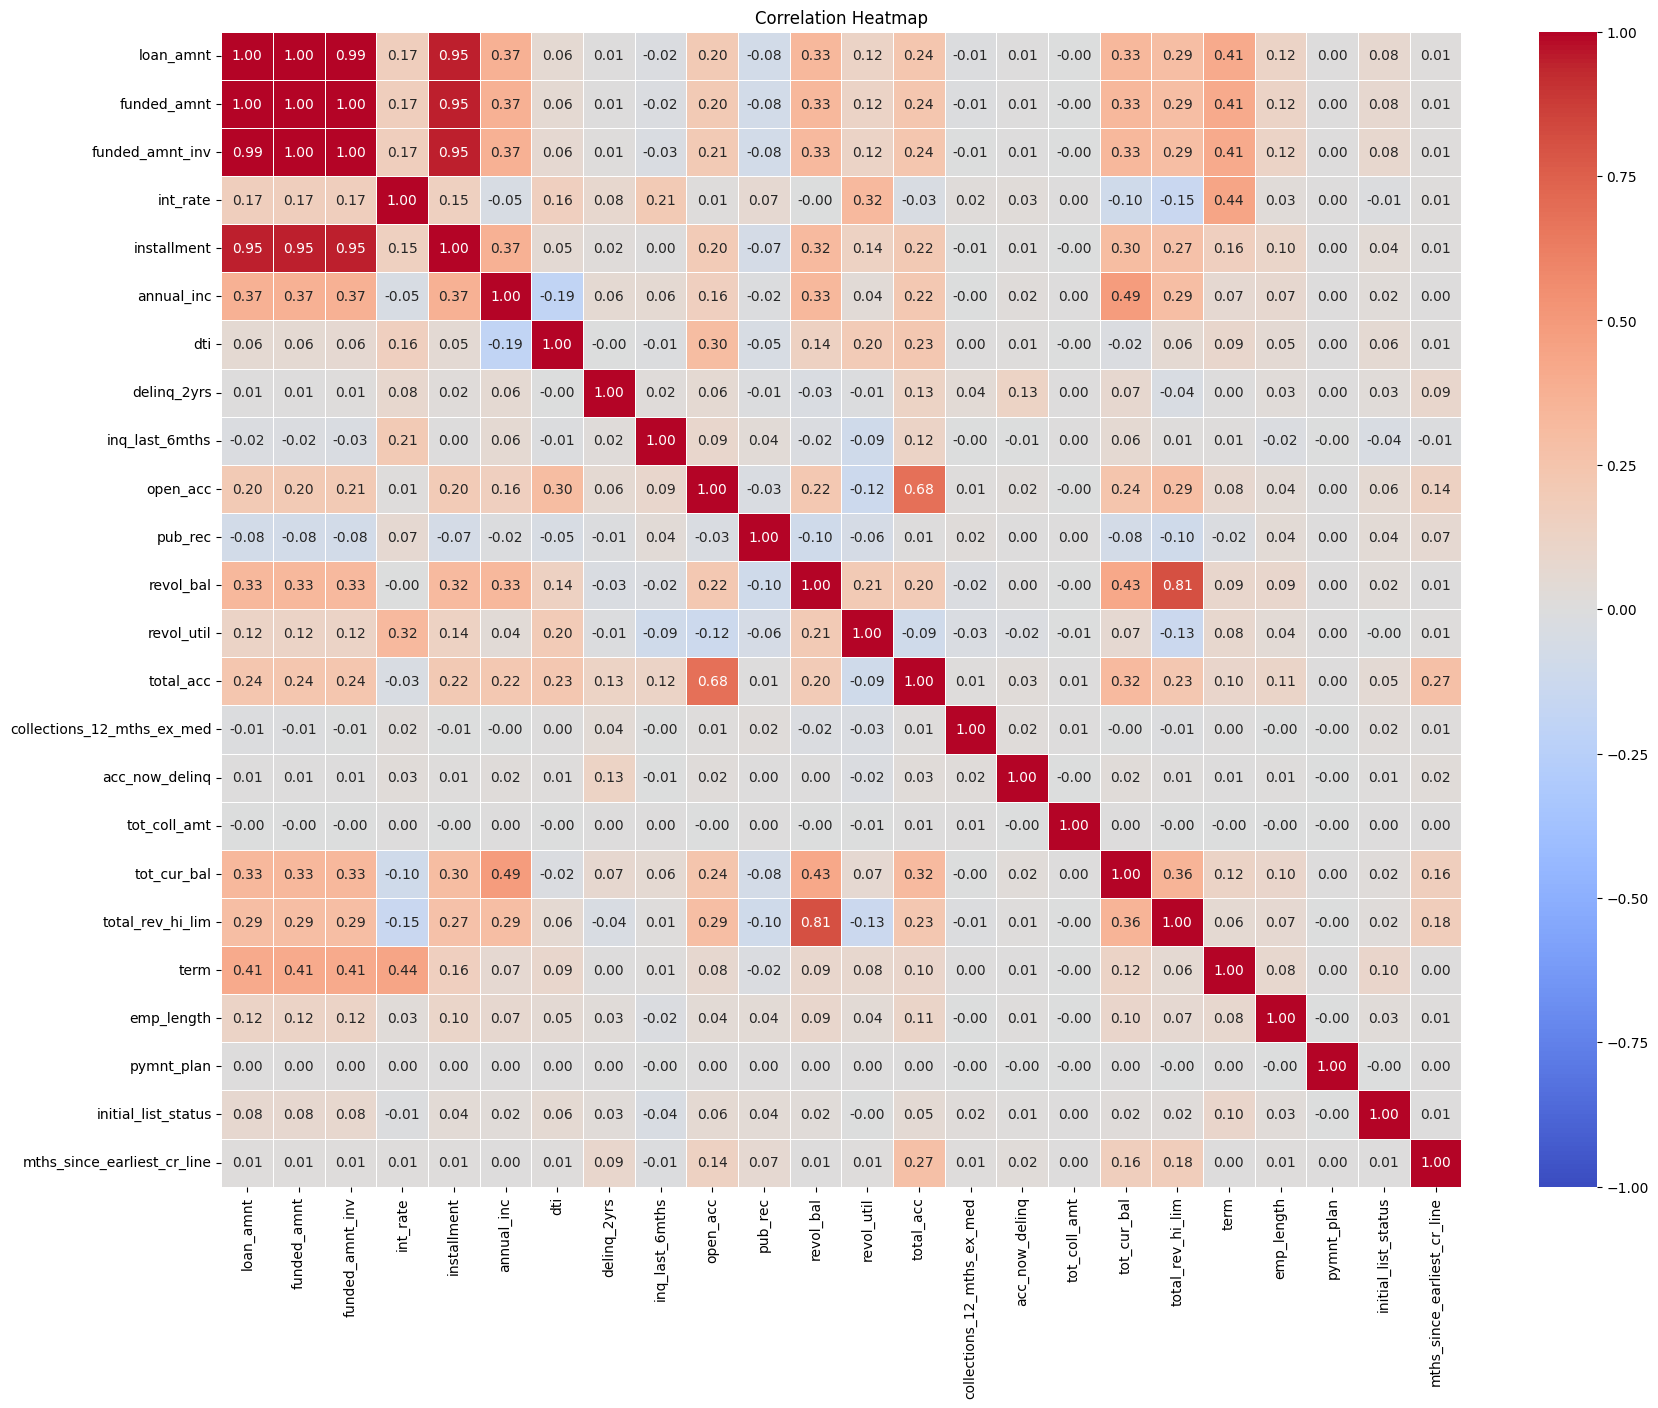

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = skim_result[skim_result['dtype'] != 'object']['feature'].tolist()
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            vmin=-1, vmax=1,
            linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

Dari heatmap di atas, dapat terlihat ada empat fitur yang memiliki korelasi yang tinggi terhadap fitur lainnya, yaitu `loan_amnt`, `funded_amnt`, `funded_amnt_inv`, dan `installment`. Saya akan memilih `loan_amnt` dan membuang tiga fitur yang lain, karena `loan_amnt` lebih menggambarkan kebutuhan sisi nasabah.

In [63]:
high_corr_features = ['funded_amnt', 'funded_amnt_inv', 'installment']
df = df.drop(columns=high_corr_features)
skim_result = utils.skim_data(df)

skim_result

Total duplicate rows: 0
DF shape: (466285, 28)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1352,0.29,"[5000, 2500, 2400, 10000, 3000]"
1,int_rate,float64,0.000,0.0,0.0,506,0.11,"[10.65, 15.27, 15.96, 13.49, 12.69]"
2,grade,object,0.000,-,-,7,0.00,"[B, C, A, E, F]"
3,sub_grade,object,0.000,-,-,35,0.01,"[B2, C4, C5, C1, B5]"
4,home_ownership,object,0.000,-,-,6,0.00,"[RENT, OWN, MORTGAGE, OTHER, NONE]"
5,annual_inc,float64,0.001,0.0,0.0,31901,6.84,"[24000.0, 30000.0, 12252.0, 49200.0, 80000.0]"
6,verification_status,object,0.000,-,-,3,0.00,"[Verified, Source Verified, Not Verified]"
7,purpose,object,0.000,-,-,14,0.00,"[credit_card, car, small_business, other, wedd..."
8,addr_state,object,0.000,-,-,50,0.01,"[AZ, GA, IL, CA, OR]"
9,dti,float64,0.000,0.0,0.078,3997,0.86,"[27.65, 1.0, 8.72, 20.0, 17.94]"


### Sanity Check

#### Low-variance Features

Dari semua fitur yang telah disaring dan dibuat baru, mari cek `skim_result` terkini. Ada tiga fitur yang memiliki nilai 0 lebih dari 99% data, yaitu `collections_12_mths_ex_med`, `acc_now_delinq`, dan `pymnt_plan`. Ini menunjukkan kalau ketiga fitur tersebut bersifat *low-variance* sehingga tidak bermanfaat dalam pembuatan model.

In [64]:
low_var_features = ['collections_12_mths_ex_med', 'acc_now_delinq', 'pymnt_plan']
df = df.drop(columns=low_var_features)
skim_result = utils.skim_data(df)

skim_result

Total duplicate rows: 0
DF shape: (466285, 25)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1352,0.29,"[5000, 2500, 2400, 10000, 3000]"
1,int_rate,float64,0.000,0.0,0.0,506,0.11,"[10.65, 15.27, 15.96, 13.49, 12.69]"
2,grade,object,0.000,-,-,7,0.00,"[B, C, A, E, F]"
3,sub_grade,object,0.000,-,-,35,0.01,"[B2, C4, C5, C1, B5]"
4,home_ownership,object,0.000,-,-,6,0.00,"[RENT, OWN, MORTGAGE, OTHER, NONE]"
5,annual_inc,float64,0.001,0.0,0.0,31901,6.84,"[24000.0, 30000.0, 12252.0, 49200.0, 80000.0]"
6,verification_status,object,0.000,-,-,3,0.00,"[Verified, Source Verified, Not Verified]"
7,purpose,object,0.000,-,-,14,0.00,"[credit_card, car, small_business, other, wedd..."
8,addr_state,object,0.000,-,-,50,0.01,"[AZ, GA, IL, CA, OR]"
9,dti,float64,0.000,0.0,0.078,3997,0.86,"[27.65, 1.0, 8.72, 20.0, 17.94]"


#### Invalid rows

Terlihat juga nilai negatif muncul pada fitur `mths_since_earliest_cr_line`. Ini tidak seharusnya terjadi karena `issue_d` tercatat sesudah `earliest_cr_line`. Ini adalah data kotor, dan lebih baik dihapus baris data yang mengandung nilai tersebut.

In [65]:
initial_shape = df.shape[0]
is_invalid = df['mths_since_earliest_cr_line'] < 0
df = df[~is_invalid]
skim_result = utils.skim_data(df)
cleaned_shape = df.shape[0]
print(f'Rows deleted: {initial_shape - cleaned_shape}')

skim_result

Total duplicate rows: 0
DF shape: (465087, 25)
Rows deleted: 1198


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1352,0.29,"[5000, 2500, 2400, 10000, 3000]"
1,int_rate,float64,0.000,0.0,0.0,506,0.11,"[10.65, 15.27, 15.96, 13.49, 12.69]"
2,grade,object,0.000,-,-,7,0.00,"[B, C, A, E, F]"
3,sub_grade,object,0.000,-,-,35,0.01,"[B2, C4, C5, C1, B5]"
4,home_ownership,object,0.000,-,-,6,0.00,"[RENT, OWN, MORTGAGE, OTHER, NONE]"
5,annual_inc,float64,0.000,0.0,0.0,31785,6.83,"[24000.0, 30000.0, 12252.0, 49200.0, 80000.0]"
6,verification_status,object,0.000,-,-,3,0.00,"[Verified, Source Verified, Not Verified]"
7,purpose,object,0.000,-,-,14,0.00,"[credit_card, car, small_business, other, wedd..."
8,addr_state,object,0.000,-,-,50,0.01,"[AZ, GA, IL, CA, OR]"
9,dti,float64,0.000,0.0,0.078,3997,0.86,"[27.65, 1.0, 8.72, 20.0, 17.94]"


Terdapat 1198 baris data yang mengandung nilai negatif untuk fitur `mths_since_earliest_cr_line`, semuanya telah dihapus.

#### Redundant Features

Selanjutnya, terdapat masalah redundansi antara `grade` dan `sub_grade` dalam arti informasinya; `sub_grade` sudah mencakup `grade` dengan informasi level yang lebih detil. Saya akan memilih `sub_grade` karena level detil informasinya lebih tinggi dibanding `grade`, dengan harapan dapat meningkatkan performa dari model.

In [66]:
print(f'Grade values: {df['grade'].unique()}')
print(f'\nSubgrade values: {df['sub_grade'].unique()}')

Grade values: ['B' 'C' 'A' 'E' 'F' 'D' 'G']

Subgrade values: ['B2' 'C4' 'C5' 'C1' 'B5' 'A4' 'E1' 'F2' 'C3' 'B1' 'D1' 'A1' 'B3' 'B4'
 'C2' 'D2' 'A3' 'A5' 'D5' 'A2' 'E4' 'D3' 'D4' 'F3' 'E3' 'F4' 'F1' 'E5'
 'G4' 'E2' 'G3' 'G2' 'G1' 'F5' 'G5']


In [67]:
df = df.drop(columns=['grade'])
skim_result = utils.skim_data(df)

skim_result

Total duplicate rows: 0
DF shape: (465087, 24)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1352,0.29,"[5000, 2500, 2400, 10000, 3000]"
1,int_rate,float64,0.000,0.0,0.0,506,0.11,"[10.65, 15.27, 15.96, 13.49, 12.69]"
2,sub_grade,object,0.000,-,-,35,0.01,"[B2, C4, C5, C1, B5]"
3,home_ownership,object,0.000,-,-,6,0.00,"[RENT, OWN, MORTGAGE, OTHER, NONE]"
4,annual_inc,float64,0.000,0.0,0.0,31785,6.83,"[24000.0, 30000.0, 12252.0, 49200.0, 80000.0]"
5,verification_status,object,0.000,-,-,3,0.00,"[Verified, Source Verified, Not Verified]"
6,purpose,object,0.000,-,-,14,0.00,"[credit_card, car, small_business, other, wedd..."
7,addr_state,object,0.000,-,-,50,0.01,"[AZ, GA, IL, CA, OR]"
8,dti,float64,0.000,0.0,0.078,3997,0.86,"[27.65, 1.0, 8.72, 20.0, 17.94]"
9,delinq_2yrs,float64,0.000,0.0,82.148,24,0.01,"[0.0, 2.0, 3.0, 1.0, 4.0]"


In [68]:
sub_grade_order = [
    'A1', 'A2', 'A3', 'A4', 'A5',
    'B1', 'B2', 'B3', 'B4', 'B5',
    'C1', 'C2', 'C3', 'C4', 'C5',
    'D1', 'D2', 'D3', 'D4', 'D5',
    'E1', 'E2', 'E3', 'E4', 'E5',
    'F1', 'F2', 'F3', 'F4', 'F5',
    'G1', 'G2', 'G3', 'G4', 'G5'
]
df['sub_grade'] = pd.Categorical(
    df['sub_grade'], categories=sub_grade_order, ordered=True
).codes
skim_result = utils.skim_data(df)

skim_result

Total duplicate rows: 0
DF shape: (465087, 24)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1352,0.29,"[5000, 2500, 2400, 10000, 3000]"
1,int_rate,float64,0.000,0.0,0.0,506,0.11,"[10.65, 15.27, 15.96, 13.49, 12.69]"
2,sub_grade,int8,0.000,0.0,2.257,35,0.01,"[6, 13, 14, 10, 9]"
3,home_ownership,object,0.000,-,-,6,0.00,"[RENT, OWN, MORTGAGE, OTHER, NONE]"
4,annual_inc,float64,0.000,0.0,0.0,31785,6.83,"[24000.0, 30000.0, 12252.0, 49200.0, 80000.0]"
5,verification_status,object,0.000,-,-,3,0.00,"[Verified, Source Verified, Not Verified]"
6,purpose,object,0.000,-,-,14,0.00,"[credit_card, car, small_business, other, wedd..."
7,addr_state,object,0.000,-,-,50,0.01,"[AZ, GA, IL, CA, OR]"
8,dti,float64,0.000,0.0,0.078,3997,0.86,"[27.65, 1.0, 8.72, 20.0, 17.94]"
9,delinq_2yrs,float64,0.000,0.0,82.148,24,0.01,"[0.0, 2.0, 3.0, 1.0, 4.0]"


#### Defining "Good Loan" vs. "Bad Loan"

Tujuan utama model yang akan dibuat adalah untuk menjawal pertanyaan bisnis sederhana: "apakah nasabah ini akan Gagal Bayar di masa depan", yang membuat permasalahan ini menjadi masalah klasifikasi biner.

Dalam `loan_status` sekarang, ada sembilan nilai unik yang harus dipilah agar dapat menjadi 1 (Gagal Bayar) atau 0 (Sukses Bayar):

In [69]:
df['loan_status'].unique()

array(['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

Untuk memilih kelompok Gagal Bayar, saya akan memilih semua variasi `Charged Off`, `Default`, dan variasi `Late (x days)`, karena saya ingin model ini secara proaktif mengidentifikasi calon nasabah yang berpotensi menyebabkan kerugian finansial bagi perusahaan.

Untuk memilih kelompok Sukses Bayar, saya akan memilih semua variasi `Fully Paid`, karena ini adalah mayoritas nasabah yang baik dan menguntungkan. Model harus bisa membedakan mereka dari kelompok berisiko.

Baris data yang tidak tergolong dalam dua kelompok di atas akan dibuang.

In [70]:
print(f'DataFrame sizes before selection: {df.shape}\n')
good_loan_statuses = [
    'Fully Paid', 
    'Does not meet the credit policy. Status:Fully Paid'
]
bad_loan_statuses = [
    'Charged Off', 
    'Default', 
    'Late (31-120 days)', 
    'Late (16-30 days)',
    'Does not meet the credit policy. Status:Charged Off'
]
df = df[df['loan_status'].isin(good_loan_statuses + bad_loan_statuses)].copy()
df['loan_status_binary'] = df['loan_status'].apply(
    lambda x: 1 if x in bad_loan_statuses else 0
)
# remove loan_status and replace with loan_status_binary
df = df.drop(columns=['loan_status'])
df = df.rename(columns={'loan_status_binary': 'loan_status'})
skim_result = utils.skim_data(df)

skim_result

DataFrame sizes before selection: (465087, 24)

Total duplicate rows: 0
DF shape: (238366, 24)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1310,0.55,"[5000, 2500, 2400, 10000, 3000]"
1,int_rate,float64,0.000,0.0,0.0,505,0.21,"[10.65, 15.27, 15.96, 13.49, 7.9]"
2,sub_grade,int8,0.000,0.0,2.297,35,0.01,"[6, 13, 14, 10, 3]"
3,home_ownership,object,0.000,-,-,6,0.00,"[RENT, OWN, MORTGAGE, OTHER, NONE]"
4,annual_inc,float64,0.000,0.0,0.0,18665,7.83,"[24000.0, 30000.0, 12252.0, 49200.0, 36000.0]"
5,verification_status,object,0.000,-,-,3,0.00,"[Verified, Source Verified, Not Verified]"
6,purpose,object,0.000,-,-,14,0.01,"[credit_card, car, small_business, other, wedd..."
7,addr_state,object,0.000,-,-,50,0.02,"[AZ, GA, IL, CA, TX]"
8,dti,float64,0.000,0.0,0.125,3912,1.64,"[27.65, 1.0, 8.72, 20.0, 11.2]"
9,delinq_2yrs,float64,0.000,0.0,83.975,23,0.01,"[0.0, 2.0, 3.0, 1.0, 4.0]"


Terlihat ada pengurangan sebanyak 226.721 baris data dari `loan_status` berlabel `Current` dan `In Grace Period`. Sekilas ini terlihat seperti pemborosan data, tapi saya berpegang teguh bahwa kualitas data lebih penting daripada kuantitas data. Data tersebut adalah noise, dan mempertahankan noise akan berakibat fatal yang dapat merusak kemampuan model untuk belajar.

In [85]:
df['purpose'].unique()

array(['credit_card', 'car', 'small_business', 'other', 'wedding',
       'debt_consolidation', 'home_improvement', 'major_purchase',
       'medical', 'moving', 'vacation', 'house', 'renewable_energy',
       'educational'], dtype=object)

### Exploratory Data Analysis

#### Splitting Data

In [71]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['loan_status'])
y = df[['loan_status']]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=29, stratify=y
)

In [72]:
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (190692, 23)
X_test shape: (47674, 23)


#### Skewness Check

Saya ingin melihat kemiringan pada distribusi masing-masing fitur numerik untuk dapat menilai metode imputasi apa yang paling tepat.

In [75]:
def skewness_check(X):
    skim_result = utils.skim_data(X)
    no_object_clause = skim_result['dtype'] != 'object'
    numeric_cols = skim_result[no_object_clause]['feature'].tolist()
    comparison = pd.DataFrame({
        'Mean': X[numeric_cols].mean(),
        'Median': X[numeric_cols].median()
    })
    comparison['Skew_Direction'] = comparison.apply(
        lambda x: 'Right Skewed (+)' if x['Mean'] > x['Median'] else 'Left Skewed (-)', axis=1
    )
    display(comparison)

skewness_check(X_train)

Total duplicate rows: 0
DF shape: (190692, 23)


,Mean,Median,Skew_Direction
loan_amnt,13499.006906,12000.000,Right Skewed (+)
int_rate,13.860614,13.670,Right Skewed (+)
sub_grade,11.017258,10.000,Right Skewed (+)
annual_inc,71984.132182,61906.585,Right Skewed (+)
dti,16.438728,16.140,Right Skewed (+)
delinq_2yrs,0.249166,0.000,Right Skewed (+)
inq_last_6mths,0.904196,1.000,Left Skewed (-)
open_acc,10.863738,10.000,Right Skewed (+)
pub_rec,0.134835,0.000,Right Skewed (+)
revol_bal,15245.956050,11001.000,Right Skewed (+)


Semua fitur numerik terlihat memiliki skewness, yang berarti apabila ada missing values, akan lebih baik jika menggunakan median untuk proses imputasi.

#### Categorical Features

In [87]:
X_skim_data = utils.skim_data(X_train)
display(X_skim_data[X_skim_data['dtype'] == 'object'])

Total duplicate rows: 0
DF shape: (190692, 23)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
3,home_ownership,object,0.0,-,-,6,0.00,"[RENT, MORTGAGE, OWN, OTHER, NONE]"
5,verification_status,object,0.0,-,-,3,0.00,"[Not Verified, Source Verified, Verified]"
6,purpose,object,0.0,-,-,14,0.01,"[major_purchase, debt_consolidation, credit_ca..."
7,addr_state,object,0.0,-,-,50,0.03,"[AZ, NY, IL, NV, CA]"


Fitur-fitur ini tidak akan bisa digunakan secara langsung; biasanya akan diproses melalui proses transformasi bernama Encoding agar tipe fiturnya menjadi numerik. Dari keempat fitur kategorikal, hanya `verification_status` yang bersifat ordinal karena kategorinya memiliki tingkatan. `home_ownership`, `purpose`, dan `addr_state` bukan. Tiga kategori tersebut memiliki jumlah n_unique yang besar, dan nantinya akan dilakukan One-Hot Encoding. Tapi apabila dilakukan OHE, maka jumlah fiturnya akan membengkak (6 + 14 + 50 = 70 fitur). Maka dari itu, saya ingin melihat perbedaan signifikan untuk Gagal Bayar pada setiap kategori.

In [90]:
df_train = pd.concat([X_train, y_train], axis=1)

def avg_default(df, feature):
    risk = df.groupby(feature)['loan_status'].mean().sort_values(ascending=False)
    print('Top 3 High-Risk Type')
    display(risk.head(3))
    print('\nBottom 3 High-Risk Type')
    display(risk.tail(3))
    print(f"\nSelisih Risk Tertinggi vs Terendah: {risk.max() - risk.min():.2%}")

avg_default(df_train, 'home_ownership')

Top 3 High-Risk Type


home_ownership
RENT        0.239636
OWN         0.232181
MORTGAGE    0.197468
Name: loan_status, dtype: float64


Bottom 3 High-Risk Type


home_ownership
OTHER    0.177305
NONE     0.131579
ANY      0.000000
Name: loan_status, dtype: float64


Selisih Risk Tertinggi vs Terendah: 23.96%


In [91]:
avg_default(df_train, 'purpose')

Top 3 High-Risk Type


purpose
small_business    0.327325
other             0.247291
moving            0.237434
Name: loan_status, dtype: float64


Bottom 3 High-Risk Type


purpose
major_purchase    0.159417
car               0.141253
wedding           0.140221
Name: loan_status, dtype: float64


Selisih Risk Tertinggi vs Terendah: 18.71%


In [92]:
avg_default(df_train, 'addr_state')

Top 3 High-Risk Type


addr_state
NE    0.666667
MS    0.372549
TN    0.312605
Name: loan_status, dtype: float64


Bottom 3 High-Risk Type


addr_state
DC    0.126806
ID    0.125000
ME    0.000000
Name: loan_status, dtype: float64


Selisih Risk Tertinggi vs Terendah: 66.67%


Terlihat dari penjabaran di atas, bahwa selisih risk untuk ketiga fitur tersebut melebihi 5%, yang dapat saya anggap cukup signifikan sehingga harus dipertahankan. Tapi bagaimana dengan isu curse of dimensionality? Dalam konteks ini, saya bisa melihat solusinya dari cara saya memperlihatkan signifikansi fitur-fitur ini: membuat encoding hanya `Top-n + 1` dari data yang ada. Ini akan memangkas jumlah fitur dengan cukup banyak.

### Embedded Feature Selection

Embedded method adalah salah satu pilihan teknik dalam memilih dan memilah fitur-fitur yang dianggap penting. Caranya adalah dengan menggunakan suatu metode ML tanpa hyperparameter tuning yang rumit. Nantinya, model tersebut dapat menyimpan skor penting dari tiap fitur. Harapannya dengan menggunakan metode ini dapat mengefektifkan jumlah fitur yang diperlukan untuk membuat model terbaik.

Langkah yang perlu dilakukan adalah:

- Memecah data menjadi data training dan test.
- Melatih algoritma ML (saya memilih Random Forest) menggunakan data train.
- Ekstraksi skor dari tiap fitur.
- Sortir fitur-fitur yang tidak diperlukan dari masing-masing data train dan test.

#### Train Feature Selector

In [73]:
from sklearn.ensemble import RandomForestClassifier

X_skim_result = utils.skim_data(X_train)
numeric_cols = X_skim_result[X_skim_result['dtype'] != 'object']['feature'].tolist()
selector_rf = RandomForestClassifier(n_estimators=100, random_state=29, n_jobs=-1)
selector_rf.fit(X_train[numeric_cols], y_train)

Total duplicate rows: 0
DF shape: (190692, 23)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


#### Extracting Feature Scores

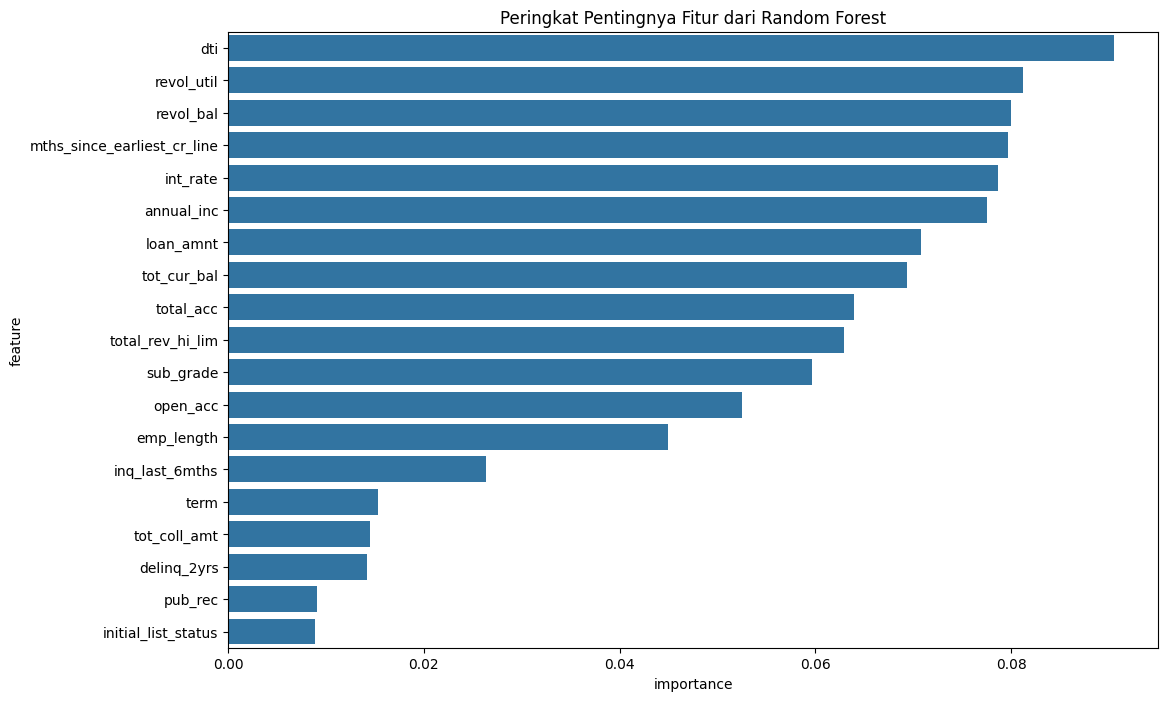

In [76]:
importances = selector_rf.feature_importances_
feature_names = X_train[numeric_cols].columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Peringkat Pentingnya Fitur dari Random Forest')
plt.show()

#### Filter Necessary Features

In [82]:
from sklearn.feature_selection import SelectFromModel

# Inisialisasi selector, menggunakan model RF yang sudah dilatih
# threshold='median' akan memilih fitur yang lebih penting dari median
selector = SelectFromModel(selector_rf, prefit=True, threshold='median') 

# Dapatkan daftar nama fitur yang terpilih
selected_features_mask = selector.get_support()
selected_feature_names = X_train[numeric_cols].columns[selected_features_mask].tolist()

print(f"Jumlah fitur awal: {X_train.shape[1]}")
print(f"Jumlah fitur terpilih: {len(selected_feature_names)}")
print("Fitur terpilih:", selected_feature_names)

Jumlah fitur awal: 23
Jumlah fitur terpilih: 10
Fitur terpilih: ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'revol_bal', 'revol_util', 'total_acc', 'tot_cur_bal', 'total_rev_hi_lim', 'mths_since_earliest_cr_line']


In [84]:
# Hitung rata-rata default (Bad Loan = 1) per negara bagian
df_train = pd.concat([X_train, y_train], axis=1)
state_risk = df_train.groupby('addr_state')['loan_status'].mean().sort_values(ascending=False)

print("Top 5 Negara Bagian Paling Berisiko (Default Rate Tinggi):")
print(state_risk.head())

print("\nBottom 5 Negara Bagian Paling Aman:")
print(state_risk.tail())

# Cek variansi-nya
print(f"\nSelisih Risk Tertinggi vs Terendah: {state_risk.max() - state_risk.min():.2%}")

Top 5 Negara Bagian Paling Berisiko (Default Rate Tinggi):
addr_state
NE    0.666667
MS    0.372549
TN    0.312605
IN    0.284933
AL    0.252936
Name: loan_status, dtype: float64

Bottom 5 Negara Bagian Paling Aman:
addr_state
NH    0.167610
WY    0.153675
DC    0.126806
ID    0.125000
ME    0.000000
Name: loan_status, dtype: float64

Selisih Risk Tertinggi vs Terendah: 66.67%
